# Import Libraries

In [1]:
from pydoc_data.topics import topics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load The Dataset

In [2]:
df = pd.read_csv('../sample_data/Student_Social_Media_And_Mental_Health_Impact.csv')

In [4]:
df.shape

(5000, 13)

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [6]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

In [7]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [10]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## Exploratory Data Analysis (EDA)

## Distribution of the target

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

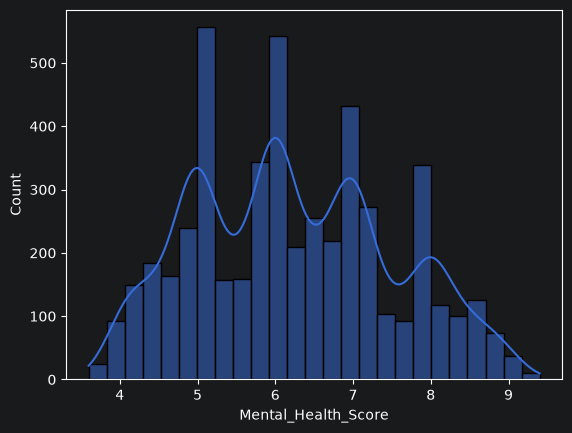

In [12]:
sns.histplot(df['Mental_Health_Score'], kde=True)

## Correlation heatmap

<Axes: >

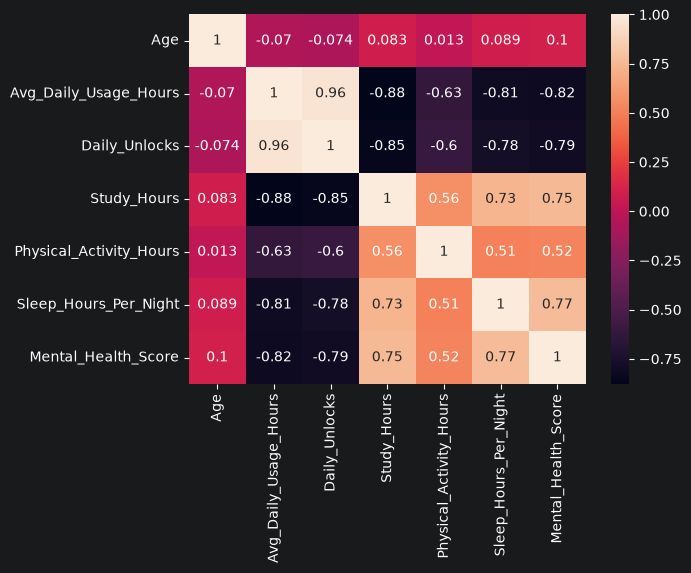

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Stress Level vs Mental Health Score

In [14]:
df['Stress_Level'].unique()

<StringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

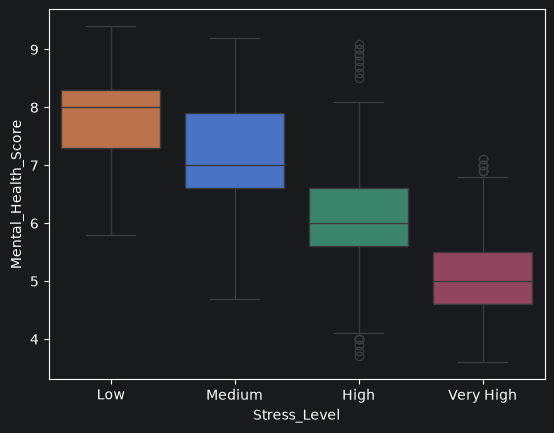

In [16]:
stress_level_order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', hue='Stress_Level', data=df, order=stress_level_order)

## Avg_Daily_Usage_Hours vs Mental_Health_Score

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

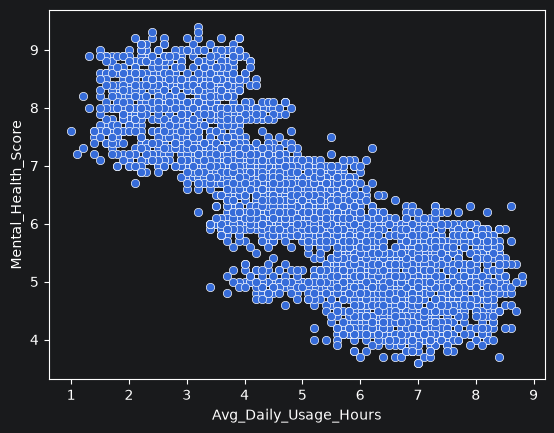

In [17]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)

## Sleep_Hours_Per_Night vs Mental_Health_Score

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

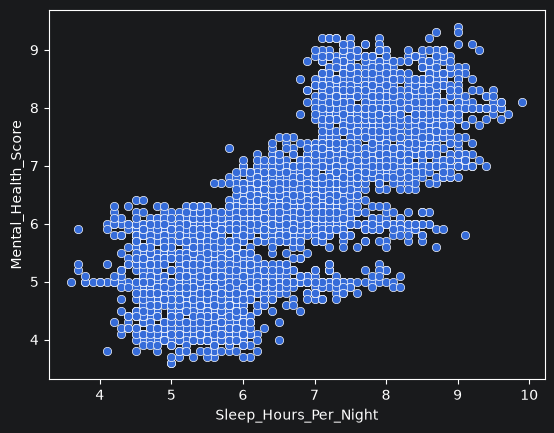

In [18]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)

## Most_Used_Platform vs Mental_Health_Score

In [21]:
platform_count = df['Most_Used_Platform'].value_counts()
platform_count

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

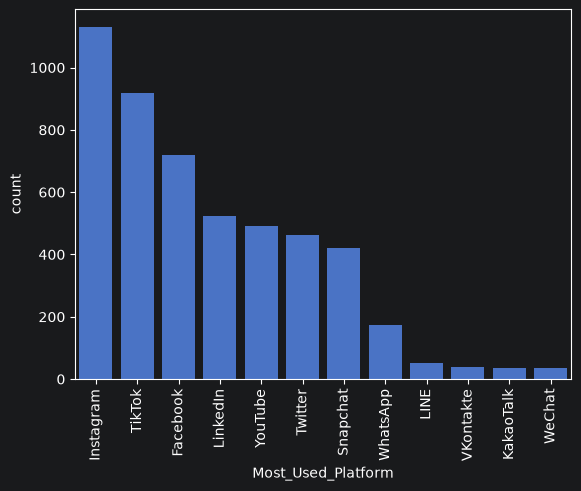

In [24]:
plt.xticks(rotation=90)
sns.countplot(x=df['Most_Used_Platform'], order=platform_count.index)

## Checking Outliers

In [27]:
num_features = df.select_dtypes(include='number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

## Data Cleaning

In [28]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
df = df.drop_duplicates()

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

## Skewness

In [29]:
num_features.skew()

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.039971
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

## Feature Engineering

In [32]:
df['Country'].value_counts()

Country
Other         1880
India          389
USA            355
Canada         230
Australia      198
              ... 
Montenegro       1
Bosnia           1
Kuwait           1
Yemen            1
Syria            1
Name: count, Length: 111, dtype: int64

In [44]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [45]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [47]:
df['Grouped_Country'] = df['Country'].apply(group_countries)
df['Grouped_Country'].value_counts()

Grouped_Country
Other        3232
India         389
USA           355
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

## Encoding Strategy

## Train Test Split

In [55]:
skewed_col = ['Study_Hours']
other_num_col = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score']
ordinal_col = ['Stress_Level']
normal_col = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Grouped_Country']

feature_col = skewed_col + other_num_col + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

## Preprocessing

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder

skewed_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler()),
])

plain_num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
])

ordinal_pipeline = Pipeline(steps=[
    ('ordinal_encoder', OrdinalEncoder(categories=[stress_level_order])),
])

nominal_pipeline = Pipeline(steps=[
    ('nominal_encoder', OneHotEncoder(handle_unknown='ignore')),
])

In [ ]:
from sklearn.compose import ColumnTransformer

ColumnTransformer(transformers=[
    ('skewed_pipeline', skewed_pipeline, skewed_col),
    ('plain_num_pipeline', plain_num_pipeline, other_num_col),
    ('ordinal_pipeline', ordinal_pipeline, ordinal_col),
    ('nominal_pipeline', nominal_pipeline, normal_col),
])

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_pipeline', ...), ('plain_num_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transfo